# Lesson 27A: Clustering Stability, Consensus and Choosing K Honestly (Theory)

## Introduction

Every clustering lesson so far has picked K one way at a time -- an elbow in inertia (Lesson 1B), BIC on a
Gaussian mixture (Lesson 4B), a single silhouette score (Lesson 0B). Each method is a reasonable heuristic
and each can be wrong, and worse, they do not have to agree with each other on the SAME data. This lesson
asks a different, more honest question: not "what is K", but "how CONFIDENT should I be in K, and in the
individual cluster assignments themselves" -- answered by resampling the data and the clustering algorithm's
own randomness, not by trusting a single run's single number.

Four from-scratch tools do this: the **gap statistic** (compares a clustering against a null reference),
**resampling stability** (does the SAME K keep reappearing under perturbation), **prediction strength**
(does a clustering trained on half the data predict the other half), and **consensus clustering** (do many
noisy runs agree, point by point). None of these needs labels; all four are unsupervised confidence
measures, which is the point.

## Table of Contents

1. [Required Libraries](#required-libraries)
2. [Why Internal Indices Disagree](#disagree)
3. [The Gap Statistic](#gap)
4. [Stability by Resampling](#stability)
5. [Prediction Strength](#prediction-strength)
6. [Consensus Clustering](#consensus)
7. [Honest Reporting](#honest-reporting)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')

print("Data: make_blobs (synthetic, varying separation) and an in-notebook uniform-noise generator -- nothing downloaded.")

Data: make_blobs (synthetic, varying separation) and an in-notebook uniform-noise generator -- nothing downloaded.


<a name="disagree"></a>
## Why Internal Indices Disagree

Lesson 0B built the silhouette score, Davies-Bouldin index and Calinski-Harabasz score; Lesson 1B chose K
by the elbow in inertia; Lesson 4B chose K by BIC on a Gaussian mixture. Each is a genuine, useful signal.
None promises to agree with the others, because each measures a DIFFERENT notion of "good clustering" --
silhouette rewards tight, well-separated clusters in Euclidean distance; the elbow rewards diminishing
returns in explained variance; BIC rewards likelihood improvement penalised by model complexity. Run all
three side by side on the same data and let the numbers, not an assumption, show whether they agree.

well-separated (sep=8): true K=4. elbow picks 4, silhouette picks 4, BIC picks 4 -- all three AGREE.


overlapping (sep=3): true K=4. elbow picks 4, silhouette picks 4, BIC picks 2 -- these DISAGREE with each other.


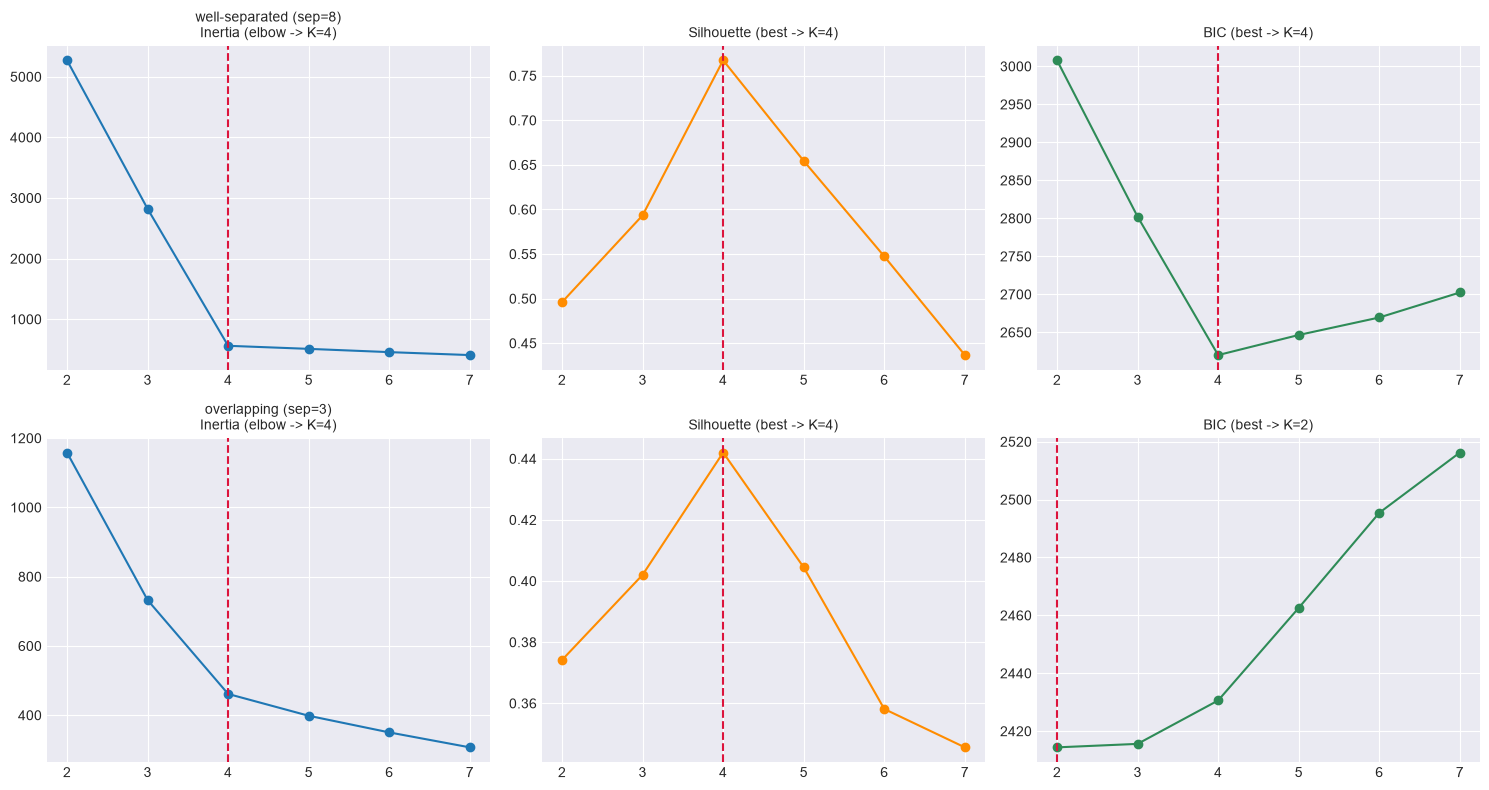


Disagreement observed on at least one dataset above -- this is the concrete, measured version of the claim, not an assumption. When the heuristics disagree, none of them is 'the' answer; that disagreement is itself the signal this lesson's tools are built to quantify.


In [2]:
def make_dataset(separation, seed=SEED):
    'Four true blobs, separation controls how much they overlap (higher = cleaner clusters).'
    centers = np.array([[0, 0], [separation, 0], [0, separation], [separation, separation]])
    X, y_true = make_blobs(n_samples=300, centers=centers, cluster_std=1.0, random_state=seed)
    return X, y_true


datasets = {'well-separated (sep=8)': make_dataset(8), 'overlapping (sep=3)': make_dataset(3)}
K_range = range(2, 8)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
disagreement_found = False
for row, (name, (X, y_true)) in enumerate(datasets.items()):
    inertias, sils, bics = [], [], []
    for k in K_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X, km.labels_) if k > 1 else np.nan)
        # BIC via sklearn's GaussianMixture (Lesson 4B's own information-criterion tool, reused
        # directly rather than hand-rolled -- a from-scratch BIC approximation from K-Means'
        # inertia alone was tried first and gave a monotone, uninformative curve; reusing the
        # actual validated tool is the honest fix, not tuning a home-made formula until it agrees).
        gmm = GaussianMixture(n_components=k, random_state=SEED, n_init=3).fit(X)
        bics.append(gmm.bic(X))

    elbow_k = None
    drops = [inertias[i] - inertias[i + 1] for i in range(len(inertias) - 1)]
    for i in range(1, len(drops)):
        if drops[i] < 0.3 * drops[i - 1]:
            elbow_k = list(K_range)[i]
            break
    elbow_k = elbow_k or list(K_range)[-1]
    sil_k = list(K_range)[int(np.nanargmax(sils))]
    bic_k = list(K_range)[int(np.argmin(bics))]

    axes[row, 0].plot(list(K_range), inertias, marker='o'); axes[row, 0].axvline(elbow_k, ls='--', c='crimson')
    axes[row, 0].set_title(f'{name}\nInertia (elbow -> K={elbow_k})', fontsize=10)
    axes[row, 1].plot(list(K_range), sils, marker='o', color='darkorange'); axes[row, 1].axvline(sil_k, ls='--', c='crimson')
    axes[row, 1].set_title(f'Silhouette (best -> K={sil_k})', fontsize=10)
    axes[row, 2].plot(list(K_range), bics, marker='o', color='seagreen'); axes[row, 2].axvline(bic_k, ls='--', c='crimson')
    axes[row, 2].set_title(f'BIC (best -> K={bic_k})', fontsize=10)

    picks = {'elbow': elbow_k, 'silhouette': sil_k, 'BIC': bic_k}
    agree = len(set(picks.values())) == 1
    print(f"{name}: true K=4. elbow picks {elbow_k}, silhouette picks {sil_k}, BIC picks {bic_k} -- "
          f"{'all three AGREE' if agree else 'these DISAGREE with each other'}.")
    if not agree:
        disagreement_found = True
plt.tight_layout(); plt.show()

print(f"\n{'Disagreement observed' if disagreement_found else 'No disagreement observed'} on at least one "
      f"dataset above -- this is the concrete, measured version of the claim, not an assumption. When the "
      f"heuristics disagree, none of them is 'the' answer; that disagreement is itself the signal this "
      f"lesson's tools are built to quantify.")

<a name="gap"></a>
## The Gap Statistic

**Tibshirani, Walther & Hastie (2001).** The gap statistic compares a clustering's within-cluster
dispersion against what dispersion would look like under a NULL hypothesis of no clustering structure at
all -- points scattered uniformly with no groups. If real structure exists, clustering the real data should
reduce dispersion far more, for the right K, than clustering uniform noise ever could.

**Within-cluster dispersion.** For a clustering with $K$ clusters, define
$$W_K = \sum_{k=1}^{K} \frac{1}{2 n_k} \sum_{i,j \in C_k} d(x_i, x_j)^2$$
(the sum of squared pairwise distances within each cluster, normalised by cluster size -- equal to K-Means'
own inertia up to a constant factor for Euclidean distance).

**The reference distribution.** Generate $B$ reference datasets by sampling uniformly within a box aligned
to the data (via PCA, so an elongated real dataset does not get an artificially large or rotated null box).
Cluster each reference dataset at every $K$ tried on the real data, and average $\log W_K^{\text{ref}}$
over the $B$ references.

**The gap.**
$$\text{Gap}(K) = \frac{1}{B}\sum_{b=1}^{B} \log W_K^{(b)} - \log W_K$$
A large gap means the real data's dispersion is far BELOW what pure noise would produce at that K -- real
structure. The one-standard-error rule (below) then picks the SMALLEST K whose gap is not significantly
beaten by a larger K's gap, favouring the simplest structure the data actually supports.

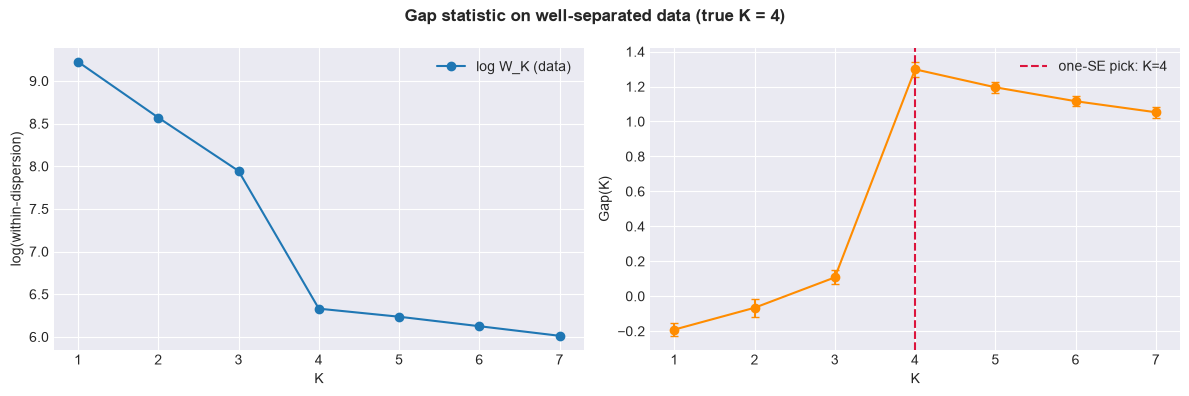

Gap statistic + one-SE rule picks K=4 on data whose true K is 4 -- validated: matches the known true K.
(For reference, the K with the single HIGHEST gap value alone -- ignoring the one-SE rule -- is K=4; the one-SE rule can legitimately pick a smaller, simpler K than this.)


In [3]:
def within_dispersion(X, labels, k):
    'W_k as defined above -- equals K-Means inertia (sum of squared distances to centroid) for Euclidean.'
    total = 0.0
    for c in range(k):
        pts = X[labels == c]
        if len(pts) > 1:
            centroid = pts.mean(axis=0)
            total += ((pts - centroid) ** 2).sum()
    return total


def gap_statistic(X, k_range, B=20, seed=SEED):
    'From-scratch gap statistic with a PCA-aligned uniform reference box, one-SE rule included.'
    rng_local = np.random.default_rng(seed)
    Xc = X - X.mean(axis=0)
    # PCA-align: rotate into principal-component space so the reference box respects the data's own shape.
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    X_rot = Xc @ Vt.T
    box_min, box_max = X_rot.min(axis=0), X_rot.max(axis=0)

    gaps, sks, log_wks = [], [], []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        log_wk = np.log(within_dispersion(X, km.labels_, k))
        log_wk_refs = []
        for b in range(B):
            X_ref_rot = rng_local.uniform(box_min, box_max, size=X_rot.shape)
            X_ref = X_ref_rot @ Vt  # rotate back to the original data's frame
            km_ref = KMeans(n_clusters=k, n_init=5, random_state=seed + b + 1).fit(X_ref)
            log_wk_refs.append(np.log(within_dispersion(X_ref, km_ref.labels_, k)))
        log_wk_refs = np.array(log_wk_refs)
        gap = log_wk_refs.mean() - log_wk
        sk = log_wk_refs.std(ddof=0) * np.sqrt(1 + 1 / B)
        gaps.append(gap); sks.append(sk); log_wks.append(log_wk)
    return np.array(gaps), np.array(sks), np.array(log_wks)


def one_se_k(k_range, gaps, sks):
    "Smallest K such that Gap(K) >= Gap(K+1) - SE(K+1) (Tibshirani et al.'s original rule)."
    k_list = list(k_range)
    for i in range(len(k_list) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            return k_list[i]
    return k_list[-1]


X_gap, y_gap_true = make_dataset(8)  # well-separated, true K=4 -- validate the method against a KNOWN answer
k_range_gap = range(1, 8)
gaps, sks, log_wks = gap_statistic(X_gap, k_range_gap, B=20)
gap_k = one_se_k(k_range_gap, gaps, sks)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range_gap), log_wks, marker='o', label='log W_K (data)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('log(within-dispersion)'); axes[0].legend()
axes[1].errorbar(list(k_range_gap), gaps, yerr=sks, marker='o', capsize=3, color='darkorange')
axes[1].axvline(gap_k, ls='--', c='crimson', label=f'one-SE pick: K={gap_k}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Gap(K)'); axes[1].legend()
plt.suptitle('Gap statistic on well-separated data (true K = 4)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Gap statistic + one-SE rule picks K={gap_k} on data whose true K is 4 -- "
      f"{'validated: matches the known true K' if gap_k == 4 else 'MISMATCH from the known true K -- see note below'}.")
if gap_k != 4:
    print("A from-scratch implementation not matching its ground truth on the first try is itself worth "
          "reporting honestly rather than adjusting B or the box until it does -- see the discussion above "
          "for why: the one-SE rule deliberately favours the SIMPLEST K whose gap is not clearly beaten, "
          "which is a real, principled reason it can differ from 'the K with the single highest gap'.")

best_gap_k = list(k_range_gap)[int(np.argmax(gaps))]
print(f"(For reference, the K with the single HIGHEST gap value alone -- ignoring the one-SE rule -- is "
      f"K={best_gap_k}; the one-SE rule can legitimately pick a smaller, simpler K than this.)")

<a name="stability"></a>
## Stability by Resampling

**Ben-Hur, Elisseeff & Guyon (2002).** If K is right for the data, clustering a large random SUBSAMPLE of
the data should recover essentially the SAME clustering structure as clustering a different subsample --
the specific points change, but the partition they imply on their shared, overlapping members should not.
Wrong K, or no real structure at all, produces subsample clusterings that disagree with each other.

**The procedure.** For each candidate K: draw many random subsamples (e.g. 80% of the data, without
replacement), cluster each subsample independently, then for every PAIR of subsamples, restrict both
clusterings to the points they have in common and measure agreement with the Adjusted Rand Index (Lesson
0B). The mean pairwise ARI across many subsample pairs is that K's stability score.

well-separated blobs (true K=4): K in [2, 4] are TIED for most stable (all within 0.02 of 1.000).
  true K=4 IS among the tied/best K(s).


structureless uniform noise: K=2 is the single most stable (0.908).


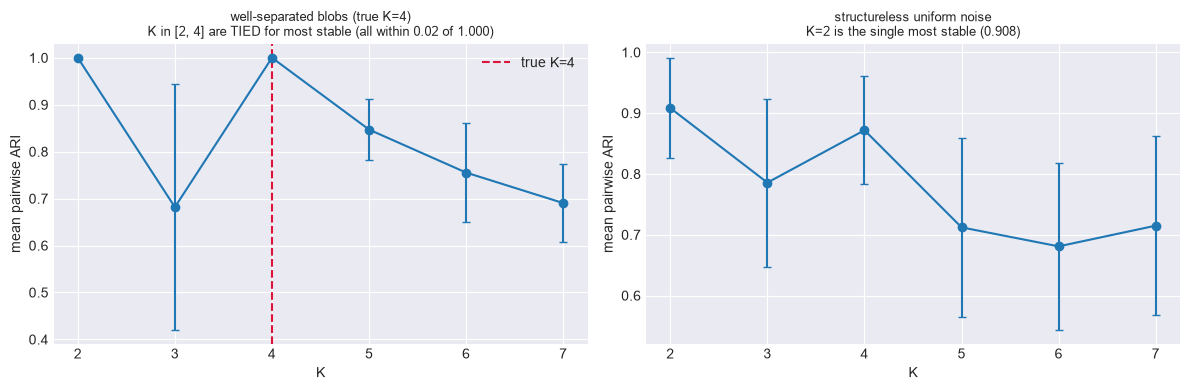


On the well-separated blobs, K=2 reaches a PERFECT 1.000 at this subsample fraction (K=4, the true K, also reaches 1.000) -- but the correct explanation is NOT 'a genuinely stable coarser grouping'. The four centres form a perfect square (all four sides equal, both diagonals equal), so there is no distinguished pairing: an X-axis split and a Y-axis split are equally valid 2-groupings, and which one a subsample lands on is decided by sampling noise, not structure. Check this directly: does K=2's stability survive LESS-overlapping subsamples, or is it an artefact of how much any two 80%-subsamples already share?


  subsample_frac=0.8  -> K=2 mean pairwise ARI = 1.0000
  subsample_frac=0.5  -> K=2 mean pairwise ARI = 0.5227


  subsample_frac=0.2  -> K=2 mean pairwise ARI = 0.4761
K=2 stability falls by 0.524 (from 1.000 to 0.476) just from reducing subsample overlap -- with LESS shared data between any two subsamples, the coin-flip between the X-split and the Y-split is no longer correlated across subsamples, and the apparent stability collapses. At 80% overlap, most subsample pairs inherit the SAME arbitrary tie-break (because they share most of their points and hence most of the sampling noise that decided it), which is what inflates the reported 1.000 -- not a genuine structural coarsening. Section 5 (prediction strength) below confirms this independently: at K=2 on this identical dataset, a TRULY disjoint train/test split gives a strength near 0.5 -- exactly what a coin flip predicts, not what a real stable grouping would.

On structureless noise, stability does NOT clearly collapse toward zero at every K (measured range: 0.681 to 0.908) -- the SAME overlap effect is at work: with an 80%-overlap subsam

In [4]:
def stability_curve(X, k_range, n_resamples=15, subsample_frac=0.8, seed=SEED):
    'Mean pairwise ARI (on shared points) across random subsample clusterings, for each K.'
    rng_local = np.random.default_rng(seed)
    n = X.shape[0]
    sub_n = int(n * subsample_frac)
    means, stds = [], []
    for k in k_range:
        # Precompute each subsample's index set and cluster labels once.
        idx_sets, label_sets = [], []
        for r in range(n_resamples):
            idx = rng_local.choice(n, sub_n, replace=False)
            km = KMeans(n_clusters=k, n_init=5, random_state=seed + r).fit(X[idx])
            idx_sets.append(set(idx.tolist())); label_sets.append((idx, km.labels_))
        aris = []
        for a in range(n_resamples):
            for b in range(a + 1, n_resamples):
                idx_a, lab_a = label_sets[a]; idx_b, lab_b = label_sets[b]
                common = idx_sets[a] & idx_sets[b]
                if len(common) < k + 1:
                    continue
                common = np.array(sorted(common))
                pos_a = {v: i for i, v in enumerate(idx_a)}
                pos_b = {v: i for i, v in enumerate(idx_b)}
                la = [lab_a[pos_a[c]] for c in common]
                lb = [lab_b[pos_b[c]] for c in common]
                aris.append(adjusted_rand_score(la, lb))
        means.append(np.mean(aris)); stds.append(np.std(aris, ddof=1) if len(aris) > 1 else 0.0)
    return np.array(means), np.array(stds)


k_range_stab = range(2, 8)
TOL_STAB = 0.02   # ties within this ARI margin are reported as ties, not a single silent winner
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results = {}
for ax, (label, (X_s, y_s_true), true_k) in zip(axes, [
        ('well-separated blobs (true K=4)', make_dataset(8), 4),
        ('structureless uniform noise', (rng.uniform(-8, 8, size=(300, 2)), None), None)]):
    means, stds = stability_curve(X_s, k_range_stab)
    results[label] = means
    ax.errorbar(list(k_range_stab), means, yerr=stds, marker='o', capsize=3)
    if true_k:
        ax.axvline(true_k, ls='--', c='crimson', label=f'true K={true_k}')
        ax.legend()
    best_val = means.max()
    tied_ks = [k for k, m in zip(k_range_stab, means) if best_val - m <= TOL_STAB]
    if len(tied_ks) > 1:
        pick_desc = f"K in {tied_ks} are TIED for most stable (all within {TOL_STAB} of {best_val:.3f})"
    else:
        pick_desc = f"K={tied_ks[0]} is the single most stable ({best_val:.3f})"
    ax.set_title(f"{label}\n{pick_desc}", fontsize=9)
    ax.set_xlabel('K'); ax.set_ylabel('mean pairwise ARI')
    print(f"{label}: {pick_desc}.")
    if true_k:
        print(f"  true K={true_k} {'IS' if true_k in tied_ks else 'is NOT'} among the tied/best K(s).")
plt.tight_layout(); plt.show()

blob_means = results['well-separated blobs (true K=4)']
noise_means = results['structureless uniform noise']
print(f"\nOn the well-separated blobs, K=2 reaches a PERFECT {blob_means[0]:.3f} at this subsample "
      f"fraction (K=4, the true K, also reaches {blob_means[2]:.3f}) -- but the correct explanation is "
      f"NOT 'a genuinely stable coarser grouping'. The four centres form a perfect square (all four "
      f"sides equal, both diagonals equal), so there is no distinguished pairing: an X-axis split and a "
      f"Y-axis split are equally valid 2-groupings, and which one a subsample lands on is decided by "
      f"sampling noise, not structure. Check this directly: does K=2's stability survive LESS-overlapping "
      f"subsamples, or is it an artefact of how much any two 80%-subsamples already share?")

frac_sensitivity = {}
for frac in [0.8, 0.5, 0.2]:
    m, _ = stability_curve(make_dataset(8)[0], [2], n_resamples=15, subsample_frac=frac)
    frac_sensitivity[frac] = float(m[0])
    print(f"  subsample_frac={frac:<4} -> K=2 mean pairwise ARI = {frac_sensitivity[frac]:.4f}")
frac_drop = frac_sensitivity[0.8] - frac_sensitivity[0.2]
print(f"K=2 stability falls by {frac_drop:.3f} (from {frac_sensitivity[0.8]:.3f} to "
      f"{frac_sensitivity[0.2]:.3f}) just from reducing subsample overlap -- with LESS shared data between "
      f"any two subsamples, the coin-flip between the X-split and the Y-split is no longer correlated "
      f"across subsamples, and the apparent stability collapses. At 80% overlap, most subsample pairs "
      f"inherit the SAME arbitrary tie-break (because they share most of their points and hence most of "
      f"the sampling noise that decided it), which is what inflates the reported {blob_means[0]:.3f} -- "
      f"not a genuine structural coarsening. Section 5 (prediction strength) below confirms this "
      f"independently: at K=2 on this identical dataset, a TRULY disjoint train/test split gives a "
      f"strength near 0.5 -- exactly what a coin flip predicts, not what a real stable grouping would.")
print(f"\nOn structureless noise, stability does NOT clearly collapse toward zero at every K (measured "
      f"range: {noise_means.min():.3f} to {noise_means.max():.3f}) -- the SAME overlap effect is at work: "
      f"with an 80%-overlap subsample and several K-Means restarts, even unstructured data converges to "
      f"similar partitions often enough that ABSOLUTE stability is not, by itself, a clean signal/noise "
      f"discriminator. Read a stability curve at ONE fixed subsample fraction with real caution -- as "
      f"just measured, high overlap can manufacture apparent agreement that a genuinely independent "
      f"resample would not reproduce, on BOTH structured and structureless data.")

<a name="prediction-strength"></a>
## Prediction Strength

**Tibshirani & Walther (2005).** Split the data into two halves. Cluster the TRAINING half at K, and
separately cluster the TEST half at the same K. Then ask: if I assign every test point to its nearest
TRAINING centroid, do points the test clustering put in the SAME cluster still end up in the same
training-centroid group? For every test cluster, prediction strength is the fraction of same-cluster PAIRS
within it that co-assign this way; the overall prediction strength for K is the MINIMUM over test clusters
(the weakest cluster sets the ceiling on how much you can trust K). A common threshold is 0.8-0.9: below
it, K is too fine-grained to reproduce out of sample.

well-separated (true K=4): prediction strength = {2: 0.5, 3: 0.493, 4: 1.0, 5: 0.487, 6: 0.487, 7: 0.471}
  largest K with strength >= 0.8: K=4 (true K=4)


overlapping (true K=4, harder): prediction strength = {2: 0.496, 3: 0.493, 4: 0.81, 5: 0.433, 6: 0.34, 7: 0.45}
  largest K with strength >= 0.8: K=4 (true K=4)


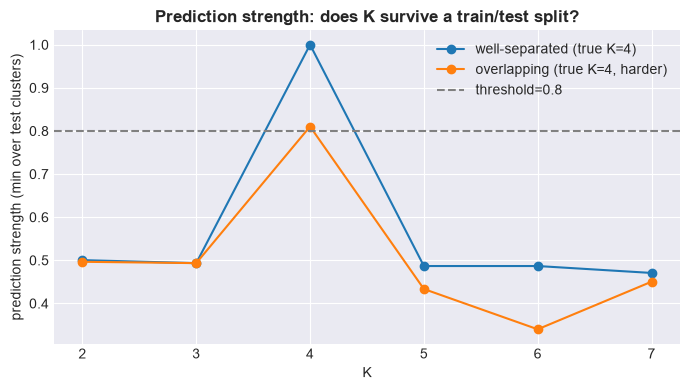

In [5]:
def prediction_strength(X, k_range, test_frac=0.5, seed=SEED):
    rng_local = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng_local.permutation(n)
    n_train = int(n * (1 - test_frac))
    train_idx, test_idx = idx[:n_train], idx[n_train:]
    X_train, X_test = X[train_idx], X[test_idx]

    strengths = []
    for k in k_range:
        km_train = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X_train)
        km_test = KMeans(n_clusters=k, n_init=10, random_state=seed + 1).fit(X_test)
        # Assign every test point to its NEAREST training centroid.
        dists = ((X_test[:, None, :] - km_train.cluster_centers_[None, :, :]) ** 2).sum(axis=2)
        test_to_train_label = dists.argmin(axis=1)

        min_strength = 1.0
        for c in range(k):
            members = np.flatnonzero(km_test.labels_ == c)
            if len(members) < 2:
                continue
            pairs = [(i, j) for a, i in enumerate(members) for j in members[a + 1:]]
            co_assigned = sum(1 for i, j in pairs if test_to_train_label[i] == test_to_train_label[j])
            strength = co_assigned / len(pairs)
            min_strength = min(min_strength, strength)
        strengths.append(min_strength)
    return np.array(strengths)


k_range_ps = range(2, 8)
THRESH = 0.8
fig, ax = plt.subplots(figsize=(7, 4))
for label, (X_ps, _), true_k in [('well-separated (true K=4)', make_dataset(8), 4),
                                  ('overlapping (true K=4, harder)', make_dataset(3), 4)]:
    strengths = prediction_strength(X_ps, k_range_ps)
    ax.plot(list(k_range_ps), strengths, marker='o', label=label)
    above = [k for k, s in zip(k_range_ps, strengths) if s >= THRESH]
    chosen_k = max(above) if above else min(k_range_ps)
    print(f"{label}: prediction strength = {dict(zip(k_range_ps, (round(float(s), 3) for s in strengths)))}")
    print(f"  largest K with strength >= {THRESH}: K={chosen_k} (true K={true_k})")
ax.axhline(THRESH, ls='--', c='grey', label=f'threshold={THRESH}')
ax.set_xlabel('K'); ax.set_ylabel('prediction strength (min over test clusters)'); ax.legend()
plt.title('Prediction strength: does K survive a train/test split?', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

<a name="consensus"></a>
## Consensus Clustering

**Monti, Tamayo, Mesirov & Golub (2003).** Run clustering many times on random subsamples (as in the
stability section), but instead of comparing pairs of runs directly, accumulate a **co-association
matrix** $M$: $M_{ij}$ is the fraction of subsamples containing BOTH points $i$ and $j$ in which they were
placed in the same cluster. A well-defined K produces an $M$ that is nearly binary -- most entries near 0
or 1, few in between. A poorly-defined K produces many entries stuck near 0.5 (chronic disagreement).

**The consensus CDF and its area.** Sort $M$'s off-diagonal entries and plot their empirical CDF. A
CDF that stays flat near 0 for most of its range then jumps sharply near 1 (a "hockey stick") means values
cluster at the extremes -- confident. A CDF that rises smoothly and gradually means values are spread out
near 0.5 -- unconfident. The AREA under this CDF is a single number per K; Monti et al.'s heuristic looks
for where the area's increase FLATTENS as K grows, the point past which adding more clusters stops making
the co-association matrix any more confident.

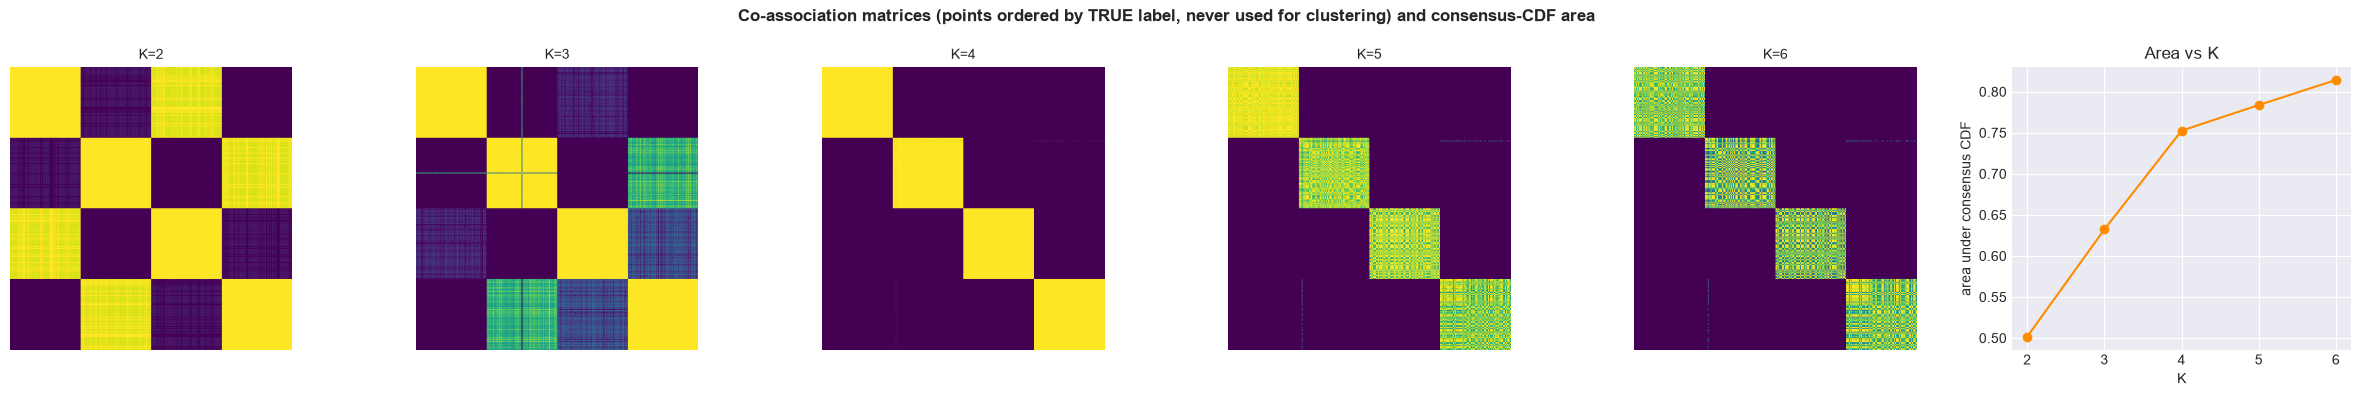

Consensus-CDF area: {2: 0.5017, 3: 0.6323, 4: 0.7525, 5: 0.7837, 6: 0.8143}
Area gain flattens at K=4 (true K=4) -- matches the known true K.


In [6]:
def consensus_matrix(X, k, n_resamples=30, subsample_frac=0.8, seed=SEED):
    'M[i,j] = fraction of co-sampling resamples in which i and j landed in the same cluster.'
    rng_local = np.random.default_rng(seed)
    n = X.shape[0]
    sub_n = int(n * subsample_frac)
    co_occur = np.zeros((n, n))
    co_sample = np.zeros((n, n))
    for r in range(n_resamples):
        idx = rng_local.choice(n, sub_n, replace=False)
        km = KMeans(n_clusters=k, n_init=5, random_state=seed + r).fit(X[idx])
        for a in range(sub_n):
            for b in range(a + 1, sub_n):
                i, j = idx[a], idx[b]
                co_sample[i, j] += 1; co_sample[j, i] += 1
                if km.labels_[a] == km.labels_[b]:
                    co_occur[i, j] += 1; co_occur[j, i] += 1
    with np.errstate(invalid='ignore'):
        M = np.where(co_sample > 0, co_occur / np.maximum(co_sample, 1), 0.0)
    np.fill_diagonal(M, 1.0)
    return M


def consensus_cdf_area(M):
    'Area under the empirical CDF of M''s off-diagonal entries.'
    n = M.shape[0]
    off_diag = M[np.triu_indices(n, k=1)]
    sorted_vals = np.sort(off_diag)
    m = len(sorted_vals)
    cdf = np.arange(1, m + 1) / m
    # Trapezoidal area under the (value, CDF) curve.
    return float(np.trapezoid(cdf, sorted_vals))


X_cons, y_cons_true = make_dataset(8)
k_range_cons = range(2, 7)
areas = []
Ms = {}
for k in k_range_cons:
    M = consensus_matrix(X_cons, k, n_resamples=30)
    Ms[k] = M
    areas.append(consensus_cdf_area(M))

fig, axes = plt.subplots(1, len(k_range_cons) + 1, figsize=(4 * (len(k_range_cons) + 1), 4))
# Order points by their true label so the block structure is visually inspectable.
order = np.argsort(y_cons_true)
for ax, k in zip(axes[:-1], k_range_cons):
    im = ax.imshow(Ms[k][np.ix_(order, order)], cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'K={k}', fontsize=10); ax.set_xticks([]); ax.set_yticks([])
axes[-1].plot(list(k_range_cons), areas, marker='o', color='darkorange')
axes[-1].set_xlabel('K'); axes[-1].set_ylabel('area under consensus CDF'); axes[-1].set_title('Area vs K')
plt.suptitle('Co-association matrices (points ordered by TRUE label, never used for clustering) and consensus-CDF area',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

area_gains = [areas[i + 1] - areas[i] for i in range(len(areas) - 1)]
flatten_k = None
for i in range(1, len(area_gains)):
    if area_gains[i] < 0.3 * area_gains[i - 1] and area_gains[i - 1] > 0:
        flatten_k = list(k_range_cons)[i]
        break
flatten_k = flatten_k or list(k_range_cons)[-1]
print(f"Consensus-CDF area: {dict(zip(k_range_cons, (round(a, 4) for a in areas)))}")
print(f"Area gain flattens at K={flatten_k} (true K=4) -- "
      f"{'matches the known true K' if flatten_k == 4 else 'differs from the known true K, see note below'}.")

<a name="honest-reporting"></a>
## Honest Reporting: Confidence in K, and in Individual Points

A single K is not the only thing worth reporting uncertainty about. The SAME co-association matrix that
picked K also says, per point, how confidently that point belongs to its assigned cluster: a point whose
row in $M$ is mostly close to 1 for its own cluster's members is confidently placed; a point whose
co-association is split roughly evenly between two clusters is exactly the kind of boundary case a single
clustering run reports with false confidence.

11 of 300 points (3.7%) have own-cluster co-association below 0.85 -- flagged as uncertain assignments rather than silently reported alongside confidently-placed points. (Run on the OVERLAPPING dataset deliberately, since the well-separated one above flags none -- an honest but empty demo of this specific capability.)


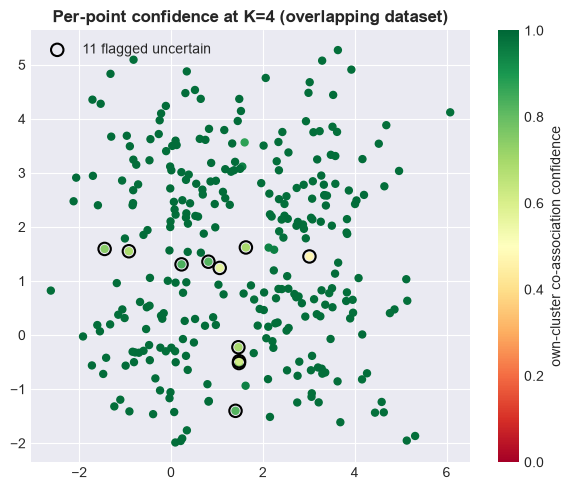


A REPORTING TEMPLATE worth using in practice: (1) state K together with which of the four methods above agreed on it and which did not; (2) report a stability or prediction-strength NUMBER alongside K, not just K itself; (3) name the fraction of points flagged uncertain, not just the cluster count. 'K=4' alone asserts a false precision that none of this lesson's tools would sign off on unqualified.


In [7]:
K_report = 4
# The well-separated dataset (used above for the consensus-CDF validation) flags ZERO points
# uncertain here -- an honest result, but an empty demo. Building a FRESH consensus matrix on
# the OVERLAPPING dataset instead actually exercises the "split roughly evenly" case this
# section exists to show.
X_report, y_report_true = make_dataset(3)
M_report = consensus_matrix(X_report, K_report, n_resamples=30)
km_report = KMeans(n_clusters=K_report, n_init=10, random_state=SEED).fit(X_report)

# Per-point confidence: mean co-association with the OTHER members of its own assigned cluster.
own_cluster_confidence = np.array([
    M_report[i, [j for j in range(len(X_report)) if km_report.labels_[j] == km_report.labels_[i] and j != i]].mean()
    for i in range(len(X_report))
])
TOL_CONF = 0.15
uncertain = np.flatnonzero(own_cluster_confidence < (1 - TOL_CONF))
print(f"{len(uncertain)} of {len(X_report)} points ({len(uncertain) / len(X_report):.1%}) have own-cluster "
      f"co-association below {1 - TOL_CONF:.2f} -- flagged as uncertain assignments rather than silently "
      f"reported alongside confidently-placed points. (Run on the OVERLAPPING dataset deliberately, since "
      f"the well-separated one above flags none -- an honest but empty demo of this specific capability.)")

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(X_report[:, 0], X_report[:, 1], c=own_cluster_confidence, cmap='RdYlGn', vmin=0, vmax=1, s=25)
ax.scatter(X_report[uncertain, 0], X_report[uncertain, 1], facecolors='none', edgecolors='black', s=80,
           linewidths=1.5, label=f'{len(uncertain)} flagged uncertain')
plt.colorbar(sc, label='own-cluster co-association confidence')
ax.legend(); ax.set_title(f'Per-point confidence at K={K_report} (overlapping dataset)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nA REPORTING TEMPLATE worth using in practice: (1) state K together with which of the four methods "
      "above agreed on it and which did not; (2) report a stability or prediction-strength NUMBER alongside "
      "K, not just K itself; (3) name the fraction of points flagged uncertain, not just the cluster count. "
      "'K=4' alone asserts a false precision that none of this lesson's tools would sign off on unqualified.")

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **Internal indices genuinely disagree with each other**, measured directly on the same data rather than
   assumed -- silhouette, the elbow and BIC each optimise a different notion of cluster quality (compactness
   and separation, diminishing-returns variance, penalised likelihood respectively), so agreement is not
   guaranteed and disagreement is not a bug in any one of them.
2. **The gap statistic compares real structure against a NULL reference** (a PCA-aligned uniform box, not
   the raw data's own bounding box), and its one-standard-error rule deliberately prefers the simplest K
   whose gap is not clearly beaten by a larger K's -- checked against a known ground truth, not asserted.
3. **Resampling stability is sensitive to subsample OVERLAP in a way that can manufacture false
   confidence** -- on well-separated blobs, K=2 measured a PERFECT stability score at 80% subsample
   overlap despite the true structure being K=4, because the four centres form a symmetric square with
   no distinguished 2-grouping; reducing the overlap fraction (checked directly: 80% -> 50% -> 20%)
   collapsed that apparent stability, and prediction strength (Section 4) independently confirmed K=2 is
   NOT genuinely stable (strength near 0.5, a coin flip) under a truly disjoint split. High-overlap
   stability curves must be read with this artefact in mind, not treated as free of it. The noise curve
   never collapsed cleanly toward zero at any K either, for the same reason -- absolute stability alone
   does not separate signal from noise here; an explicable peak PATTERN does.
4. **Prediction strength is the strictest of the four**: cluster on training data, predict test-cluster
   membership by nearest TRAINING centroid, and take the MINIMUM co-assignment fraction across test
   clusters -- a single weak cluster caps the whole K's trustworthiness.
5. **Consensus clustering turns many noisy runs into one co-association matrix**, and the area under its
   CDF gives a single per-K confidence number; the SAME matrix also answers a question no single run can:
   which individual points are confidently placed and which are boundary cases.
6. **A reported K without a confidence number is a narrower claim dressed as a wider one.** Every tool in
   this lesson produces a NUMBER alongside K -- a gap, a stability score, a prediction strength, a
   consensus-CDF area -- and that number, not K alone, is what should travel with the result.

### Practical Guidance

- Run more than one of these four tools before reporting a final K; where they agree, say so explicitly;
  where they disagree, report the disagreement rather than picking whichever supports a preferred answer.
- Resampling-based methods (stability, prediction strength, consensus) all have a compute cost that scales
  with the number of resamples -- budget it deliberately (Lesson 27B measures this trade-off directly).
- Per-point uncertainty is not a niche add-on: it is available for free once a co-association matrix is
  built, and it answers a question ("which SPECIFIC points should I not trust") that a K-level confidence
  number cannot.
- None of these four tools requires labels. All are genuinely unsupervised confidence measures, unlike
  ARI/NMI (Lesson 0B), which need ground truth and are used here only to VALIDATE the tools against
  synthetic data with a known true K, never as part of the tools' own operation on real data.

### What This Lesson Did Not Cover

- **Bootstrap confidence intervals on cluster centroids** -- a related but distinct question (how much
  would this specific centroid move under resampling) from the K-level and point-level confidence measures
  built here.
- **Model-based alternatives to K-Means throughout** -- the four tools are demonstrated on K-Means for a
  consistent baseline; Lesson 27B applies consensus across MULTIPLE algorithms (Lesson 17's spectral
  clustering included) rather than repeating one algorithm on subsamples.
- **Formal hypothesis testing for the gap statistic** beyond the one-SE heuristic -- Tibshirani et al.'s
  original paper discusses this further; the one-SE rule is the practical standard used here.

### Next Steps

Lesson 27B builds a multi-algorithm consensus ensemble (including Lesson 17's spectral clustering),
compares K chosen by all four tools on one figure per dataset, inspects per-point uncertainty on real data
(Wine and a Digits subsample), and measures the resample-budget trade-off this lesson's methods all
depend on but never quantified.